# 05 Predictive Intelligence

In [47]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, classification_report,
    roc_curve, confusion_matrix
)
from xgboost import XGBRegressor, XGBClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
DB_PATH = Path('../data/reviews_analysis.db')

print(f'PyTorch version: {torch.__version__}')
print(f'Device: {"CUDA" if torch.cuda.is_available() else "CPU"}')


PyTorch version: 2.10.0+cu128
Device: CUDA


In [48]:
conn = sqlite3.connect(DB_PATH)
reviews = pd.read_sql('SELECT * FROM reviews', conn)
authors = pd.read_sql('SELECT id, num_cities, num_helpful_votes, num_reviews FROM authors', conn)
conn.close()

reviews['review_date'] = pd.to_datetime(reviews['review_date'], errors='coerce')
print(f'Reviews loaded: {len(reviews):,}')
print(f'Columns: {list(reviews.columns)}')
reviews.head(3)


Reviews loaded: 80,000
Columns: ['title', 'text', 'date_stayed', 'hotel_id', 'num_helpful_votes', 'review_date', 'review_id', 'via_mobile', 'service_rating', 'cleanliness_rating', 'overall_rating', 'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating', 'check_in_service_rating', 'business_service_rating', 'author_id']


,title,text,date_stayed,hotel_id,num_helpful_votes,review_date,review_id,via_mobile,service_rating,cleanliness_rating,overall_rating,value_rating,location_rating,sleep_quality_rating,rooms_rating,check_in_service_rating,business_service_rating,author_id
0,“Daaaaaa Bears!”,I recently stayed at W Chicago Lakeshore and o...,2012-11-01 00:00:00,225108,0,2012-11-19,145753174,0,5.0,5.0,5.0,5.0,5.0,5.0,5.0,NaN,NaN,714F49AC057498AEA304343E569A2A03
1,“Would go back in a heartbeat- Location Locati...,We booked this hotel after out initial travel ...,2010-09-01 00:00:00,122005,1,2010-10-02,81870377,0,3.0,5.0,4.0,5.0,5.0,5.0,3.0,NaN,NaN,74C5A4455E1AAE46B0C54FC6CCBD7033
2,"“Clean, Friendly, Affordable Alternative to Do...",I am currently here in the hotel; checking out...,2009-07-01 00:00:00,939375,2,2009-07-02,33732815,0,5.0,4.0,4.0,4.0,4.0,NaN,4.0,NaN,NaN,CC2C523A197E7024A07BE083E1573E75


---
## Problem 1a: Predict Overall Rating from Aspect Ratings


**Features:** `service`, `cleanliness`, `value`, `location`, `sleep_quality`, `rooms` ratings  
**Target:** `overall_rating` (1–5 scale)

Samples after dropping NaN: 58,190 (from 80,000)

Target distribution:
overall_rating
1.0     2646
2.0     3339
3.0     8231
4.0    19329
5.0    24645
Name: count, dtype: int64


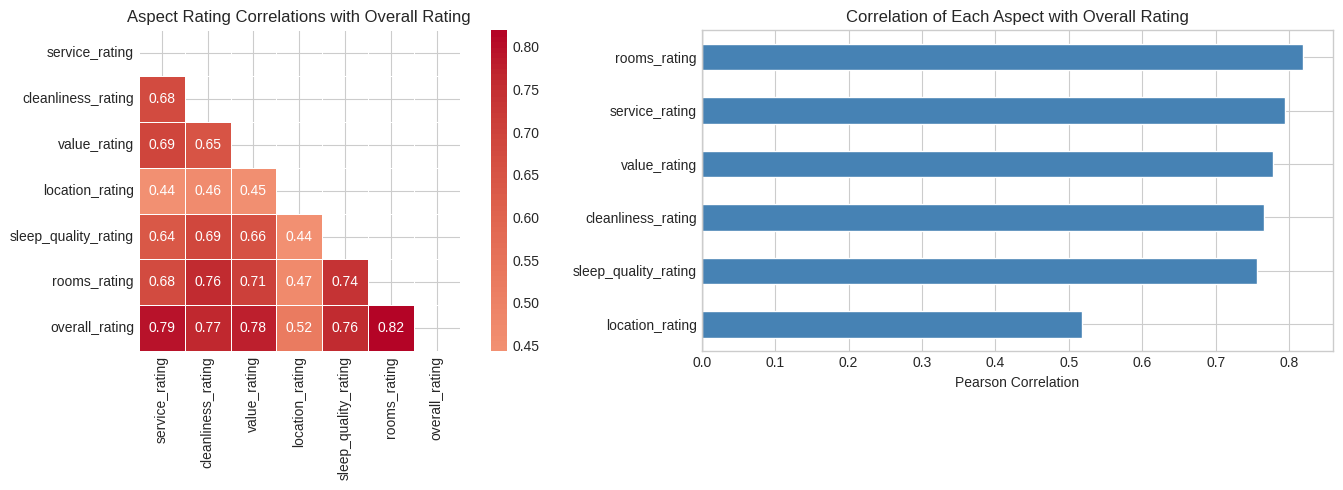

In [49]:
# Data preparation
ASPECT_COLS = ['service_rating', 'cleanliness_rating', 'value_rating',
               'location_rating', 'sleep_quality_rating', 'rooms_rating']
TARGET_1A = 'overall_rating'

df_1a = reviews[ASPECT_COLS + [TARGET_1A]].dropna()
print(f'Samples after dropping NaN: {len(df_1a):,} (from {len(reviews):,})')
print(f'\nTarget distribution:\n{df_1a[TARGET_1A].value_counts().sort_index()}')

# EDA: Correlations
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr = df_1a.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[0], cmap='coolwarm',
            center=0, square=True, mask=mask, linewidths=0.5)
axes[0].set_title('Aspect Rating Correlations with Overall Rating', fontsize=12)

corr[TARGET_1A].drop(TARGET_1A).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Correlation of Each Aspect with Overall Rating', fontsize=12)
axes[1].set_xlabel('Pearson Correlation')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()


In [50]:
# Train/ Validate / Test split (60 / 20 / 20)
X_1a = df_1a[ASPECT_COLS].values
y_1a = df_1a[TARGET_1A].values

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_1a, y_1a, test_size=0.4, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE
)

scaler_1a = StandardScaler()
X_train_s = scaler_1a.fit_transform(X_train)
X_val_s   = scaler_1a.transform(X_val)
X_test_s  = scaler_1a.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Validate: {X_val.shape[0]:,} | Test: {X_test.shape[0]:,}')

def eval_reg(y_true, y_pred, name):
    return {
        'Model': name,
        'MAE':  round(mean_absolute_error(y_true, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
        'R2':   round(r2_score(y_true, y_pred), 4)
    }

results_1a = []


Train: 34,914 | Validate: 11,638 | Test: 11,638


In [51]:
# Sklearn models
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_s, y_train)
results_1a.append(eval_reg(y_test, lr.predict(X_test_s), 'Linear Regression'))

# Ridge Regression
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_s, y_train)
results_1a.append(eval_reg(y_test, ridge.predict(X_test_s), 'Ridge Regression'))

# Random Forest (no scaling needed for tree models)
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=10,
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train, y_train)
results_1a.append(eval_reg(y_test, rf_reg.predict(X_test), 'Random Forest'))

# Gradient Boosting
gb_reg = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    max_depth=4, random_state=RANDOM_STATE)
gb_reg.fit(X_train, y_train)
results_1a.append(eval_reg(y_test, gb_reg.predict(X_test), 'Gradient Boosting'))

# XGBoost
xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                        random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)
xgb_reg.fit(X_train, y_train)
results_1a.append(eval_reg(y_test, xgb_reg.predict(X_test), 'XGBoost'))

print('Sklearn models trained:')
for r in results_1a:
    print(f"  {r['Model']:<22} MAE={r['MAE']:.4f}  RMSE={r['RMSE']:.4f}  R2={r['R2']:.4f}")

Sklearn models trained:
  Linear Regression      MAE=0.3245  RMSE=0.4583  R2=0.8199
  Ridge Regression       MAE=0.3245  RMSE=0.4583  R2=0.8199
  Random Forest          MAE=0.3148  RMSE=0.4506  R2=0.8259
  Gradient Boosting      MAE=0.3152  RMSE=0.4454  R2=0.8299
  XGBoost                MAE=0.3151  RMSE=0.4455  R2=0.8298


Early stopping at epoch 51


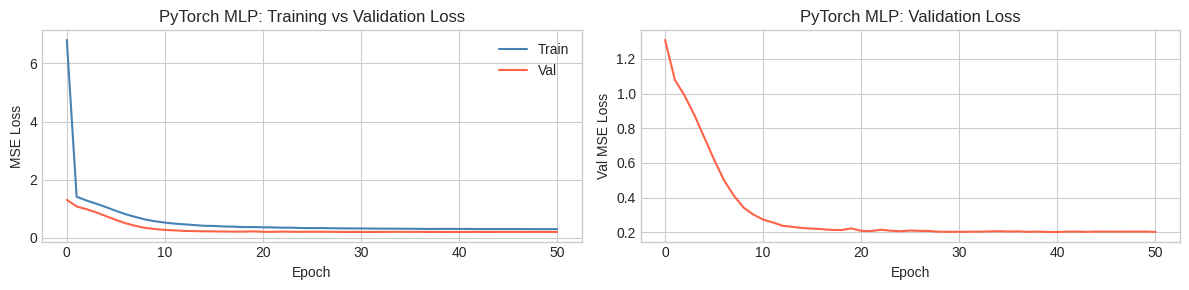

Trained for 51 epochs
Final LR: 2.50e-04
Best validation loss (MSE): 0.2023


In [52]:
# PyTorch MLP
class RatingMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Tensors for train, validate, test
X_tr_t  = torch.FloatTensor(X_train_s).to(DEVICE)
y_tr_t  = torch.FloatTensor(y_train).unsqueeze(1).to(DEVICE)
X_val_t = torch.FloatTensor(X_val_s).to(DEVICE)
y_val_t = torch.FloatTensor(y_val).unsqueeze(1).to(DEVICE)
X_te_t  = torch.FloatTensor(X_test_s).to(DEVICE)

train_dl = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=512, shuffle=True)
val_dl   = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512)

model_1a      = RatingMLP(X_train_s.shape[1]).to(DEVICE)
optimizer_1a  = optim.Adam(model_1a.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_reg = nn.MSELoss()
scheduler_1a  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_1a, mode='min', factor=0.5, patience=5
)

train_losses_1a  = []
val_losses_1a    = []
best_val_loss_1a = float('inf')
best_state_1a    = None
patience, patience_counter = 10, 0
N_EPOCHS = 80

for epoch in range(N_EPOCHS):
    # Training phase
    model_1a.train()
    epoch_loss = 0.0
    for bx, by in train_dl:
        optimizer_1a.zero_grad()
        loss = criterion_reg(model_1a(bx), by)
        loss.backward()
        optimizer_1a.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_dl)
    train_losses_1a.append(avg_train)

    # Validation phase
    model_1a.eval()
    val_loss = 0.0
    with torch.no_grad():
        for bx, by in val_dl:
            val_loss += criterion_reg(model_1a(bx), by).item()
    avg_val = val_loss / len(val_dl)
    val_losses_1a.append(avg_val)

    # LR scheduler step (halves LR if val loss stalls for 5 epochs)
    scheduler_1a.step(avg_val)

    # Early stopping
    if avg_val < best_val_loss_1a:
        best_val_loss_1a = avg_val
        best_state_1a = {k: v.clone() for k, v in model_1a.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

# Restore best weights and evaluate on test set
model_1a.load_state_dict(best_state_1a)
model_1a.eval()
with torch.no_grad():
    y_pred_mlp_1a = model_1a(X_te_t).cpu().numpy().flatten()

results_1a.append(eval_reg(y_test, y_pred_mlp_1a, 'PyTorch MLP'))

# Training and validation loss plots
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(train_losses_1a, color='steelblue', label='Train')
axes[0].plot(val_losses_1a,   color='tomato',    label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('PyTorch MLP: Training vs Validation Loss'); axes[0].legend()
axes[1].plot(val_losses_1a, color='tomato')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val MSE Loss')
axes[1].set_title('PyTorch MLP: Validation Loss')

plt.tight_layout()
plt.show()

print(f'Trained for {len(val_losses_1a)} epochs')
print(f'Final LR: {optimizer_1a.param_groups[0]["lr"]:.2e}')
print(f'Best validation loss (MSE): {best_val_loss_1a:.4f}')

=== Problem 1a Overall Rating Prediction: Model Comparison ===
               Model     MAE    RMSE      R2
1  Gradient Boosting  0.3152  0.4454  0.8299
2            XGBoost  0.3151  0.4455  0.8298
3      Random Forest  0.3148  0.4506  0.8259
4        PyTorch MLP  0.3179  0.4506  0.8259
5  Linear Regression  0.3245  0.4583  0.8199
6   Ridge Regression  0.3245  0.4583  0.8199


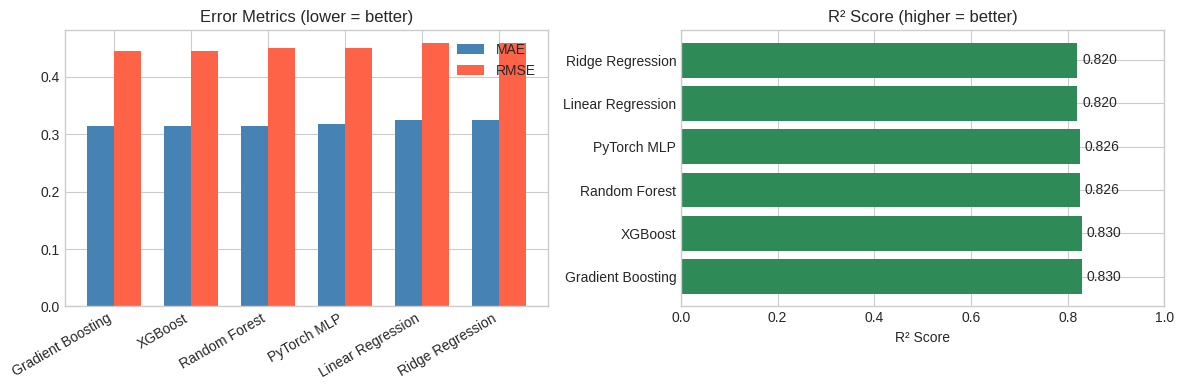

In [53]:
# Results comparison
res_1a_df = pd.DataFrame(results_1a).sort_values('RMSE').reset_index(drop=True)
res_1a_df.index += 1
print('=== Problem 1a Overall Rating Prediction: Model Comparison ===')
print(res_1a_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Model comparison bar chart
x = np.arange(len(res_1a_df))
w = 0.35
axes[0].bar(x - w/2, res_1a_df['MAE'], w, label='MAE', color='steelblue')
axes[0].bar(x + w/2, res_1a_df['RMSE'], w, label='RMSE', color='tomato')
axes[0].set_xticks(x)
axes[0].set_xticklabels(res_1a_df['Model'], rotation=30, ha='right')
axes[0].set_title('Error Metrics (lower = better)')
axes[0].legend()

# R² comparison
axes[1].barh(res_1a_df['Model'], res_1a_df['R2'], color='seagreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('R² Score (higher = better)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(res_1a_df['R2']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()


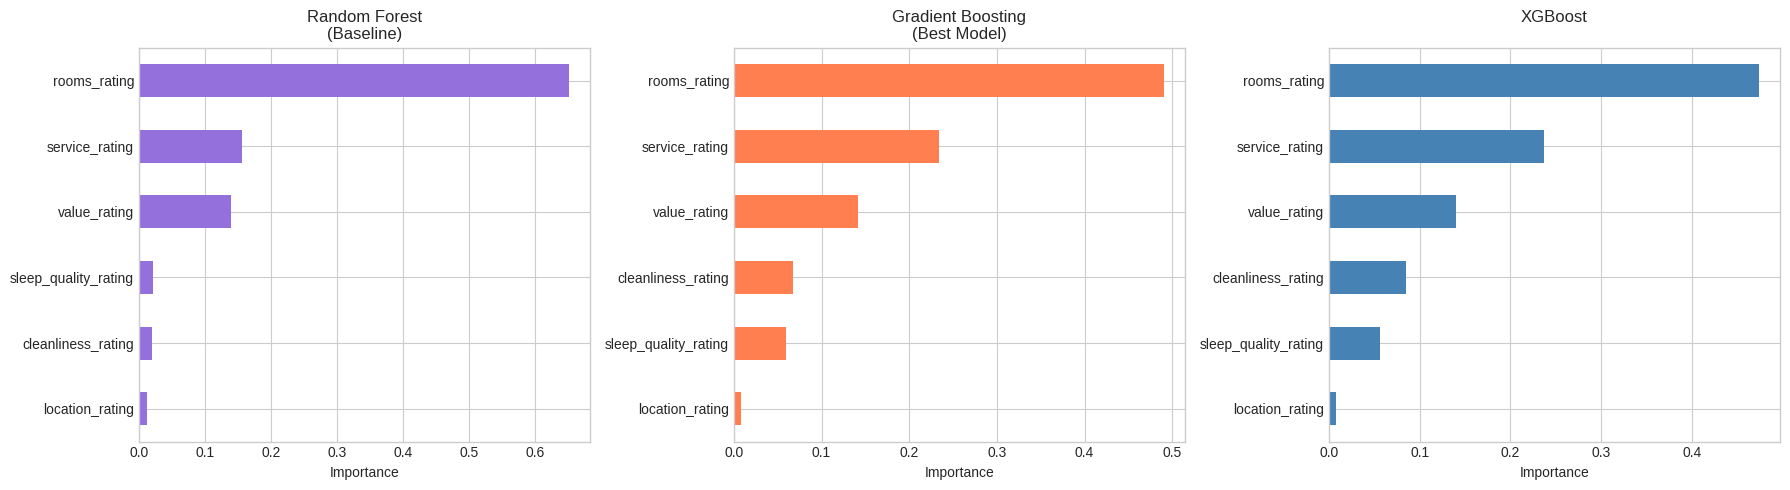

Feature importance comparison:
                      Random Forest  Gradient Boosting   XGBoost
rooms_rating               0.650360           0.490031  0.473199
service_rating             0.156508           0.234441  0.236560
value_rating               0.139195           0.141186  0.140140
sleep_quality_rating       0.021855           0.059018  0.056871
cleanliness_rating         0.020437           0.067646  0.085253
location_rating            0.011645           0.007679  0.007976

Top feature (RF): rooms_rating (importance=0.650)
Top feature (GB): rooms_rating (importance=0.490)
Top feature (XGB): rooms_rating (importance=0.473)

Recommended model: Gradient Boosting  (RMSE=0.4454, R²=0.8299)


In [54]:
# Feature importance comparison
feat_imp_rf = pd.Series(rf_reg.feature_importances_, index=ASPECT_COLS).sort_values()
feat_imp_gb = pd.Series(gb_reg.feature_importances_, index=ASPECT_COLS).sort_values()
feat_imp_xgb = pd.Series(xgb_reg.feature_importances_, index=ASPECT_COLS).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

feat_imp_rf.plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Random Forest\n(Baseline)')
axes[0].set_xlabel('Importance')

feat_imp_gb.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Gradient Boosting\n(Best Model)')
axes[1].set_xlabel('Importance')

feat_imp_xgb.plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('XGBoost\n')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

cmp = pd.DataFrame({
  'Random Forest': feat_imp_rf,
  'Gradient Boosting': feat_imp_gb,
  'XGBoost': feat_imp_xgb,
}).sort_values('Random Forest', ascending=False)

print('Feature importance comparison:')
print(cmp.to_string())
print(f'\nTop feature (RF): {feat_imp_rf.idxmax()} (importance={feat_imp_rf.max():.3f})')
print(f'Top feature (GB): {feat_imp_gb.idxmax()} (importance={feat_imp_gb.max():.3f})')
print(f'Top feature (XGB): {feat_imp_xgb.idxmax()} (importance={feat_imp_xgb.max():.3f})')

best_1a = res_1a_df.iloc[0]
print(f'\nRecommended model: {best_1a["Model"]}  (RMSE={best_1a["RMSE"]:.4f}, R²={best_1a["R2"]:.4f})')


---
## Problem 1b: Predict Review Helpfulness

**Target definition:** `is_helpful = 1` if `num_helpful_votes > 0`, else `0`.

**Feature groups:**
- Rating features: all aspect ratings + overall rating
- Text features: character count, word count, title length
- Author features: total reviews written, cities visited, author lifetime helpfulness

Dataset for 1b: 40,112 samples
Helpful rate: 41.7%
Class distribution:
is_helpful
0    23393
1    16719
Name: count, dtype: int64


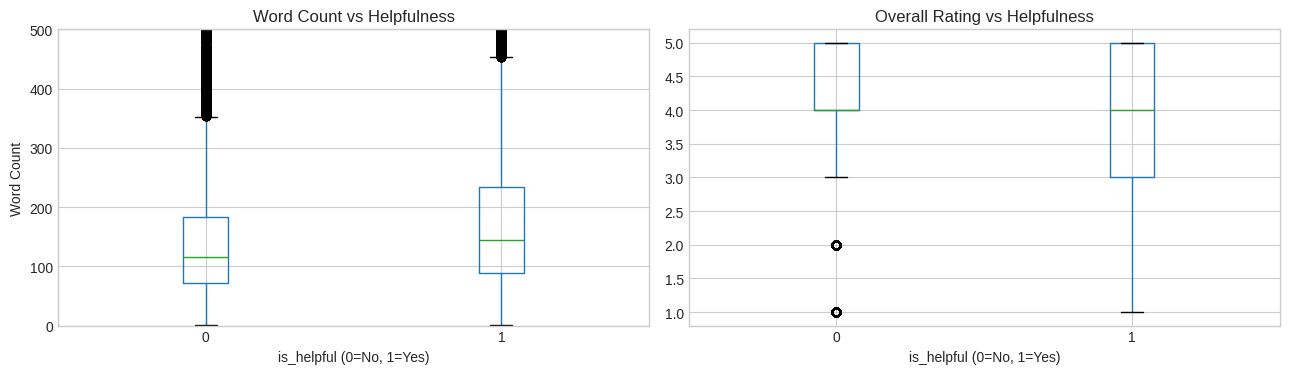

In [55]:
# Feature engineering
# Merge with author features (rename to avoid collision with review's num_helpful_votes)
authors_renamed = authors.rename(columns={
    'id': 'author_id',
    'num_helpful_votes': 'author_total_helpful_votes'
})

df_1b = reviews.merge(authors_renamed, on='author_id', how='left')

# Target
df_1b['is_helpful'] = (df_1b['num_helpful_votes'] > 0).astype(int)

# Text-derived features
df_1b['text_len']    = df_1b['text'].fillna('').str.len()
df_1b['word_count']  = df_1b['text'].fillna('').str.split().str.len()
df_1b['title_len']   = df_1b['title'].fillna('').str.len()
df_1b['has_title']   = df_1b['title'].notna().astype(int)
df_1b['via_mobile']  = df_1b['via_mobile'].fillna(0).astype(int)

FEATURE_COLS_1B = [
    'overall_rating', 'service_rating', 'cleanliness_rating',
    'value_rating', 'location_rating', 'sleep_quality_rating', 'rooms_rating',
    'via_mobile', 'text_len', 'word_count', 'title_len', 'has_title',
    'num_cities', 'author_total_helpful_votes', 'num_reviews'
]

df_1b_clean = df_1b[FEATURE_COLS_1B + ['is_helpful']].dropna()
print(f'Dataset for 1b: {len(df_1b_clean):,} samples')
print(f'Helpful rate: {df_1b_clean["is_helpful"].mean():.1%}')
print(f'Class distribution:\n{df_1b_clean["is_helpful"].value_counts()}')

# Distribution of text length vs helpfulness
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_1b_clean.boxplot(column='word_count', by='is_helpful', ax=axes[0])
axes[0].set_title('Word Count vs Helpfulness')
axes[0].set_xlabel('is_helpful (0=No, 1=Yes)')
axes[0].set_ylabel('Word Count')
axes[0].set_ylim(0, 500)

df_1b_clean.boxplot(column='overall_rating', by='is_helpful', ax=axes[1])
axes[1].set_title('Overall Rating vs Helpfulness')
axes[1].set_xlabel('is_helpful (0=No, 1=Yes)')
plt.suptitle('')

plt.tight_layout()
plt.show()


In [56]:
# Train/ Validate / Test split (60 / 20 / 20)
X_1b = df_1b_clean[FEATURE_COLS_1B].values
y_1b = df_1b_clean['is_helpful'].values

X_tr_1b, X_tmp_1b, y_tr_1b, y_tmp_1b = train_test_split(
    X_1b, y_1b, test_size=0.4, random_state=RANDOM_STATE, stratify=y_1b
)
X_val_1b, X_te_1b, y_val_1b, y_te_1b = train_test_split(
    X_tmp_1b, y_tmp_1b, test_size=0.5, random_state=RANDOM_STATE, stratify=y_tmp_1b
)

scaler_1b  = StandardScaler()
X_tr_1b_s  = scaler_1b.fit_transform(X_tr_1b)
X_val_1b_s = scaler_1b.transform(X_val_1b)
X_te_1b_s  = scaler_1b.transform(X_te_1b)

print(f'Train: {X_tr_1b.shape[0]:,} | Val: {X_val_1b.shape[0]:,} | Test: {X_te_1b.shape[0]:,}\n')
print(f'Positive rate\nTrain: {y_tr_1b.mean():.2%} | Val: {y_val_1b.mean():.2%} | Test: {y_te_1b.mean():.2%}')

def eval_clf(y_true, y_pred, y_prob, name):
    return {
        'Model':    name,
        'Accuracy': round(accuracy_score(y_true, y_pred), 4),
        'F1_macro': round(f1_score(y_true, y_pred, average='macro'), 4),
        'AUC_ROC':  round(roc_auc_score(y_true, y_prob), 4)
    }

results_1b = []


Train: 24,067 | Val: 8,022 | Test: 8,023

Positive rate
Train: 41.68% | Val: 41.69% | Test: 41.68%


In [57]:
# Sklearn models
# Logistic Regression
log_reg = LogisticRegression(class_weight='balanced', max_iter=500, random_state=RANDOM_STATE)
log_reg.fit(X_tr_1b_s, y_tr_1b)
results_1b.append(eval_clf(
    y_te_1b, log_reg.predict(X_te_1b_s),
    log_reg.predict_proba(X_te_1b_s)[:, 1], 'Logistic Regression'
))

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=200, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_clf.fit(X_tr_1b, y_tr_1b)
results_1b.append(eval_clf(
    y_te_1b, rf_clf.predict(X_te_1b),
    rf_clf.predict_proba(X_te_1b)[:, 1], 'Random Forest'
))

# Gradient Boosting
gb_clf = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                     max_depth=4, random_state=RANDOM_STATE)
gb_clf.fit(X_tr_1b, y_tr_1b)
results_1b.append(eval_clf(
    y_te_1b, gb_clf.predict(X_te_1b),
    gb_clf.predict_proba(X_te_1b)[:, 1], 'Gradient Boosting'
))

# XGBoost (scale_pos_weight handles imbalance, equivalent to class_weight='balanced')
scale_pos = (y_tr_1b == 0).sum() / (y_tr_1b == 1).sum()
xgb_clf = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                         scale_pos_weight=scale_pos,
                         random_state=RANDOM_STATE, verbosity=0, n_jobs=-1,
                         eval_metric='logloss')
xgb_clf.fit(X_tr_1b, y_tr_1b)
results_1b.append(eval_clf(
    y_te_1b, xgb_clf.predict(X_te_1b),
    xgb_clf.predict_proba(X_te_1b)[:, 1], 'XGBoost'
))

print('Sklearn models trained:')
for r in results_1b:
    print(f"  {r['Model']:<22} Acc={r['Accuracy']:.4f}  F1={r['F1_macro']:.4f}  AUC={r['AUC_ROC']:.4f}")

Sklearn models trained:
  Logistic Regression    Acc=0.5896  F1=0.5780  AUC=0.6112
  Random Forest          Acc=0.6073  F1=0.5584  AUC=0.6229
  Gradient Boosting      Acc=0.6288  F1=0.5802  AUC=0.6505
  XGBoost                Acc=0.6063  F1=0.6011  AUC=0.6497


Early stopping at epoch 40


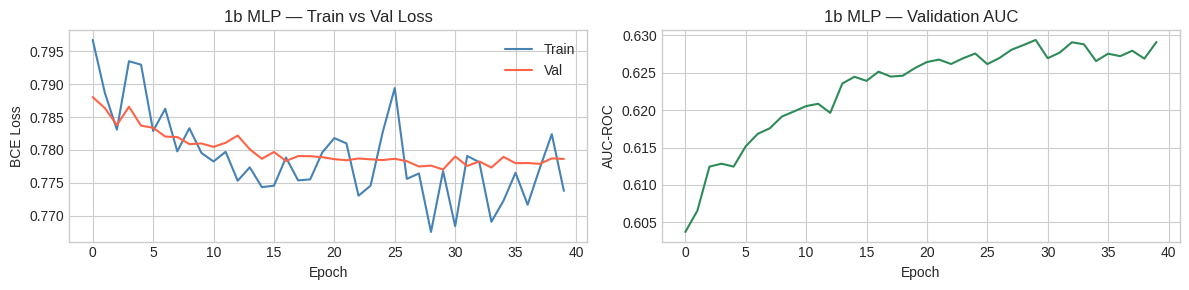

Trained for 51 epochs
Final LR: 2.50e-04
Best validation loss (MSE): 0.7770 | Best validation AUC: 0.6294


In [58]:
# PyTorch MLP
class HelpfulnessMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)  # using BCEWithLogitsLoss

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Class weight for imbalance
pos_weight = torch.tensor([(y_tr_1b == 0).sum() / (y_tr_1b == 1).sum()]).to(DEVICE)

# Tensors for train, validate, test
X_tr_1b_t  = torch.FloatTensor(X_tr_1b_s).to(DEVICE)
y_tr_1b_t  = torch.FloatTensor(y_tr_1b).unsqueeze(1).to(DEVICE)
X_val_1b_t = torch.FloatTensor(X_val_1b_s).to(DEVICE)
y_val_1b_t = torch.FloatTensor(y_val_1b).unsqueeze(1).to(DEVICE)
X_te_1b_t  = torch.FloatTensor(X_te_1b_s).to(DEVICE)

train_dl_1b = DataLoader(TensorDataset(X_tr_1b_t, y_tr_1b_t), batch_size=512, shuffle=True)
val_dl_1b   = DataLoader(TensorDataset(X_val_1b_t, y_val_1b_t), batch_size=512)

model_1b      = HelpfulnessMLP(X_tr_1b_s.shape[1]).to(DEVICE)
optimizer_1b  = optim.Adam(model_1b.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_clf = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
scheduler_1b  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_1b, mode='min', factor=0.5, patience=5
)

train_losses_1b  = []
val_losses_1b    = []
val_aucs_1b      = []
best_val_loss_1b = float('inf')
best_state_1b    = None
patience, patience_counter = 10, 0
N_EPOCHS = 80

for epoch in range(N_EPOCHS):
    # Training phase
    model_1b.train()
    epoch_loss = 0.0
    for bx, by in train_dl_1b:
        optimizer_1b.zero_grad()
        loss = criterion_clf(model_1b(bx), by)
        loss.backward()
        optimizer_1b.step()
        epoch_loss += loss.item()
    avg_train = epoch_loss / len(train_dl_1b)
    train_losses_1b.append(avg_train)

    # Validation phase
    model_1b.eval()
    val_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for bx, by in val_dl_1b:
            val_loss += criterion_clf(model_1b(bx), by).item()
            all_probs.extend(torch.sigmoid(model_1b(bx)).cpu().numpy().flatten())
            all_labels.extend(by.cpu().numpy().flatten())
    avg_val = val_loss / len(val_dl_1b)
    val_losses_1b.append(avg_val)
    val_aucs_1b.append(roc_auc_score(all_labels, all_probs))

    # LR scheduler step (halves LR if val loss stalls for 5 epochs)
    scheduler_1b.step(avg_val)

    # Early stopping
    if avg_val < best_val_loss_1b:
        best_val_loss_1b = avg_val
        best_state_1b = {k: v.clone() for k, v in model_1b.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

# Restore best weights and evaluate on test set
model_1b.load_state_dict(best_state_1b)
model_1b.eval()
with torch.no_grad():
    logits      = model_1b(X_te_1b_t).cpu().numpy().flatten()
    probs_mlp   = torch.sigmoid(torch.tensor(logits)).numpy()
    preds_mlp   = (probs_mlp >= 0.5).astype(int)

results_1b.append(eval_clf(y_te_1b, preds_mlp, probs_mlp, 'PyTorch MLP'))

# Training and validation loss plots
fig, axes = plt.subplots(1, 2, figsize=(12, 3))

axes[0].plot(train_losses_1b, color='steelblue', label='Train')
axes[0].plot(val_losses_1b,   color='tomato',    label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('1b MLP — Train vs Val Loss'); axes[0].legend()
axes[1].plot(val_aucs_1b, color='seagreen')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('1b MLP — Validation AUC')

plt.tight_layout()
plt.show()

print(f'Trained for {len(val_losses_1a)} epochs')
print(f'Final LR: {optimizer_1a.param_groups[0]["lr"]:.2e}')
print(f'Best validation loss (MSE): {best_val_loss_1b:.4f} | Best validation AUC: {max(val_aucs_1b):.4f}')


=== Problem 1b Review Helpfulness Prediction: Model Comparison ===
                 Model  Accuracy  F1_macro  AUC_ROC
1    Gradient Boosting    0.6288    0.5802   0.6505
2              XGBoost    0.6063    0.6011   0.6497
3          PyTorch MLP    0.6050    0.5979   0.6311
4        Random Forest    0.6073    0.5584   0.6229
5  Logistic Regression    0.5896    0.5780   0.6112

Classification Report: Gradient Boosting
              precision    recall  f1-score   support

 Not Helpful       0.64      0.83      0.72      4679
     Helpful       0.59      0.35      0.44      3344

    accuracy                           0.63      8023
   macro avg       0.62      0.59      0.58      8023
weighted avg       0.62      0.63      0.60      8023



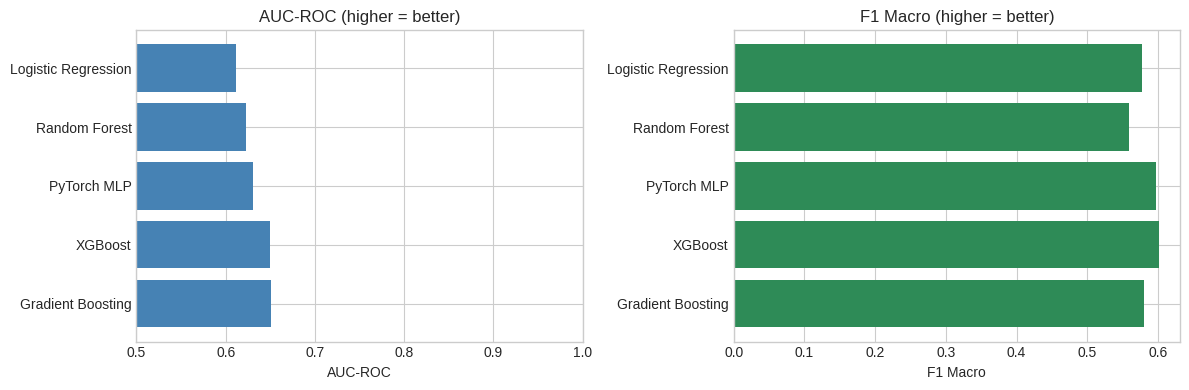

In [59]:
# Results comparison
res_1b_df = pd.DataFrame(results_1b).sort_values('AUC_ROC', ascending=False).reset_index(drop=True)
res_1b_df.index += 1
print('=== Problem 1b Review Helpfulness Prediction: Model Comparison ===')
print(res_1b_df.to_string())

# Details for best model
best_1b_name = res_1b_df.iloc[0]['Model']
model_map = {
    'Logistic Regression': (log_reg, X_te_1b_s),
    'Random Forest':       (rf_clf, X_te_1b),
    'Gradient Boosting':   (gb_clf, X_te_1b),
}
if best_1b_name in model_map:
    best_m, best_X = model_map[best_1b_name]
    print(f'\nClassification Report: {best_1b_name}')
    print(classification_report(y_te_1b, best_m.predict(best_X),
                                 target_names=['Not Helpful', 'Helpful']))

# Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].barh(res_1b_df['Model'], res_1b_df['AUC_ROC'], color='steelblue')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_title('AUC-ROC (higher = better)')
axes[0].set_xlim(0.5, 1.0)

axes[1].barh(res_1b_df['Model'], res_1b_df['F1_macro'], color='seagreen')
axes[1].set_xlabel('F1 Macro')
axes[1].set_title('F1 Macro (higher = better)')

plt.tight_layout()
plt.show()


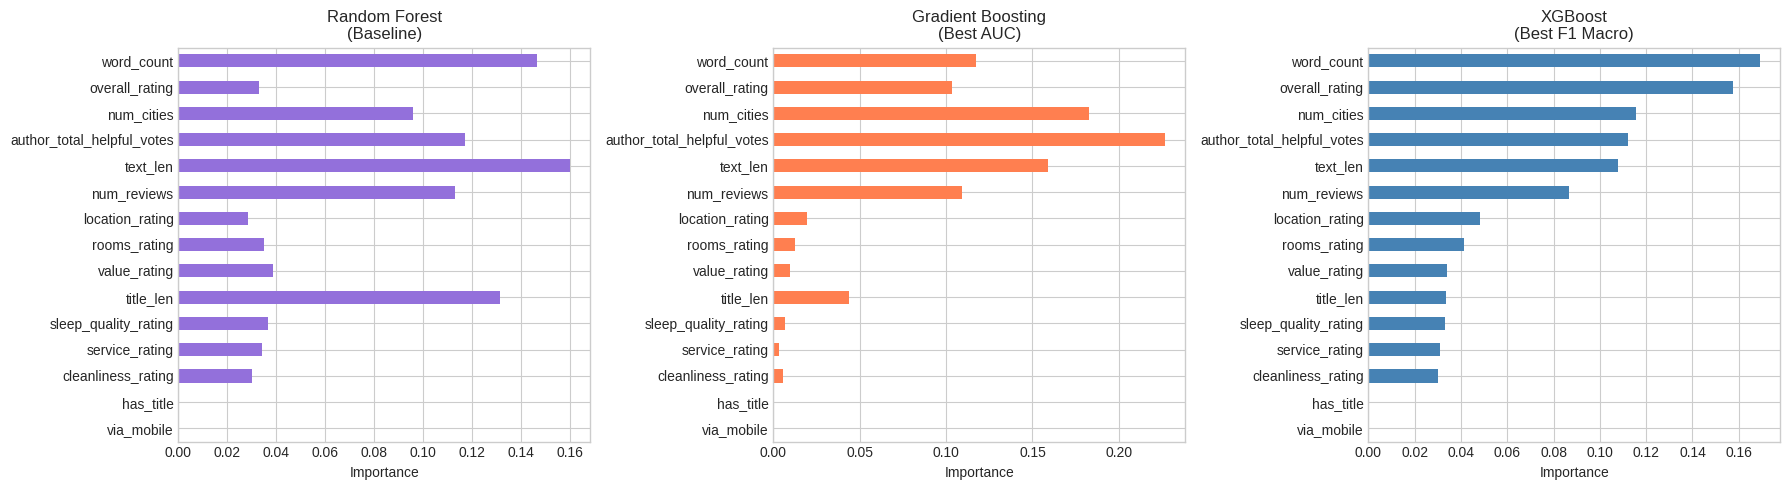

Feature importance comparison:
                            Random Forest  Gradient Boosting  XGBoost
word_count                         0.1466             0.1172   0.1693
overall_rating                     0.0328             0.1035   0.1574
num_cities                         0.0960             0.1830   0.1156
author_total_helpful_votes         0.1170             0.2270   0.1121
text_len                           0.1602             0.1591   0.1077
num_reviews                        0.1132             0.1094   0.0866
location_rating                    0.0286             0.0193   0.0480
rooms_rating                       0.0350             0.0127   0.0413
value_rating                       0.0385             0.0094   0.0340
title_len                          0.1314             0.0435   0.0334
sleep_quality_rating               0.0364             0.0069   0.0331
service_rating                     0.0341             0.0034   0.0310
cleanliness_rating                 0.0302             0.005

In [60]:
# Feature importance comparison (RF vs GB vs XGBoost)
feat_imp_rf_1b  = pd.Series(rf_clf.feature_importances_,  index=FEATURE_COLS_1B)
feat_imp_gb_1b  = pd.Series(gb_clf.feature_importances_,  index=FEATURE_COLS_1B)
feat_imp_xgb_1b = pd.Series(xgb_clf.feature_importances_, index=FEATURE_COLS_1B)

# Sort by XGBoost importance for a consistent order
order = feat_imp_xgb_1b.sort_values().index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

feat_imp_rf_1b[order].plot(kind='barh', ax=axes[0], color='mediumpurple')
axes[0].set_title('Random Forest\n(Baseline)')
axes[0].set_xlabel('Importance')

feat_imp_gb_1b[order].plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Gradient Boosting\n(Best AUC)')
axes[1].set_xlabel('Importance')

feat_imp_xgb_1b[order].plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title('XGBoost\n(Best F1 Macro)')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Side-by-side table
cmp_1b = pd.DataFrame({
    'Random Forest':      feat_imp_rf_1b,
    'Gradient Boosting':  feat_imp_gb_1b,
    'XGBoost':            feat_imp_xgb_1b,
}).sort_values('XGBoost', ascending=False)

print('Feature importance comparison:')
print(cmp_1b.round(4).to_string())
print(f'\nTop feature (RF):  {feat_imp_rf_1b.idxmax()} ({feat_imp_rf_1b.max():.4f})')
print(f'Top feature (GB):  {feat_imp_gb_1b.idxmax()} ({feat_imp_gb_1b.max():.4f})')
print(f'Top feature (XGB): {feat_imp_xgb_1b.idxmax()} ({feat_imp_xgb_1b.max():.4f})')

best_1b = res_1b_df.iloc[0]
print(f'\nRecommended model: {best_1b["Model"]}  (AUC={best_1b["AUC_ROC"]:.4f}, F1={best_1b["F1_macro"]:.4f})')


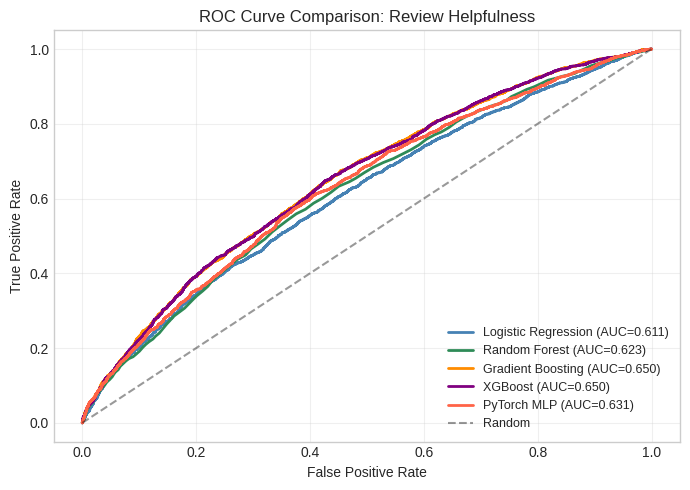

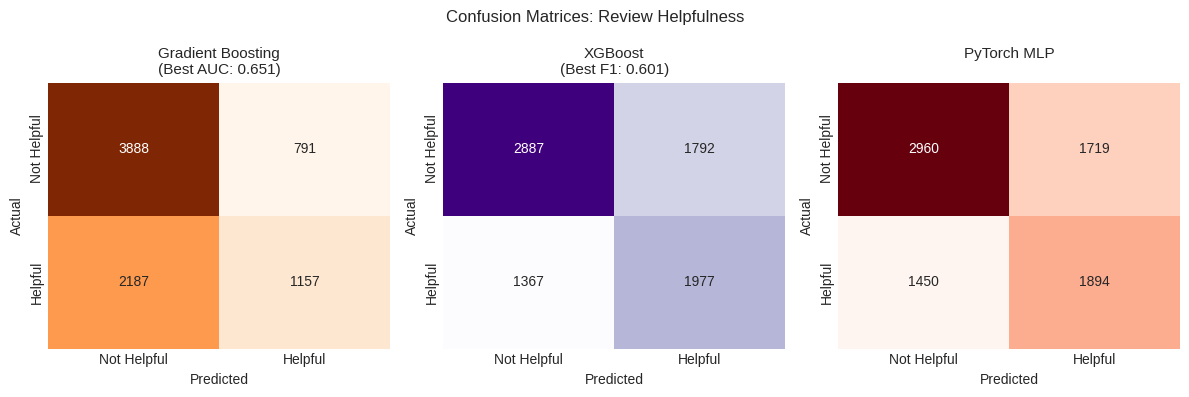

In [61]:
prob_map = {
    'Logistic Regression': (log_reg.predict_proba(X_te_1b_s)[:, 1], 'steelblue'),
    'Random Forest':       (rf_clf.predict_proba(X_te_1b)[:, 1],    'seagreen'),
    'Gradient Boosting':   (gb_clf.predict_proba(X_te_1b)[:, 1],    'darkorange'),
    'XGBoost':             (xgb_clf.predict_proba(X_te_1b)[:, 1],   'purple'),
    'PyTorch MLP':         (probs_mlp,                              'tomato'),
}

# ROC curves
fig, ax = plt.subplots(figsize=(7, 5))
for name, (probs, color) in prob_map.items():
    fpr, tpr, _ = roc_curve(y_te_1b, probs)
    auc = roc_auc_score(y_te_1b, probs)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: Review Helpfulness')
ax.legend(loc='lower right', fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Confusion matrices (GB, XGBoost, MLP)
best_1b_name = pd.DataFrame(results_1b).sort_values('AUC_ROC', ascending=False).iloc[0]['Model']
clf_preds = {
    'Logistic Regression': (log_reg.predict(X_te_1b_s), 'Blues'),
    'Random Forest':       (rf_clf.predict(X_te_1b),    'Greens'),
    'Gradient Boosting':   (gb_clf.predict(X_te_1b),    'Oranges'),
    'XGBoost':             (xgb_clf.predict(X_te_1b),   'Purples'),
    'PyTorch MLP':         (preds_mlp,                  'Reds'),
}

panels = [
    (clf_preds['Gradient Boosting'], f'Gradient Boosting\n(Best AUC: 0.651)'),
    (clf_preds['XGBoost'],           f'XGBoost\n(Best F1: 0.601)'),
    (clf_preds['PyTorch MLP'],       'PyTorch MLP\n'),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, ((preds, cmap), title) in zip(axes, panels):
    cm = confusion_matrix(y_te_1b, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Not Helpful', 'Helpful'],
                yticklabels=['Not Helpful', 'Helpful'],
                cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices: Review Helpfulness', fontsize=12)

plt.tight_layout()
plt.show()


### Problem 1: Overall Rating Prediction
- **Rooms rating has the strongest influence** on overall rating.
